# In-Class Assignment 12

## Star Formation and the Pre-Main Sequence

### Learning Objectives

- explore conditions for star formation
- compute estimated star formation rates
- qualitatively describe the hayashi track, henyey track and pre main-sequence phases

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## a. Jeans ’ mass for an average molecular cloud.

### **Individually/with the person next to you**:

1. Calculate the density for an average molecular cloud:
    * Assume $T=10$ K, $M_{\rm{cloud}}=1000M_{\odot}$ and a number density $n$ of ${\rm{H}_{2}}$ molecules of $n= 1000 (\rm{cm}^{-3})$. 
        
> Hint: Recall the mean molecular weight $\mu=\rho/n m_{\rm{H}}$.

> Hint: What is the mean molecular weight assuming the entire cloud is ${\rm{H}_{2}}$.

2. Using the density from part 1. Compute the Jeans' mass for this cloud in terms of $M_\odot$.

In [2]:
msun_cgs = 2e33# frams
n = 1000       # cm^-3
m_H = 1.67e-24 # grams
k_B = 1.38e-16 # erg / K
G_cgs = 6.67e-8

T = 10.
M = 1000.
mu = 2.

rho = mu * n * m_H
print(rho)

3.34e-21


In [3]:
M_J = ((5*k_B*T)/(mu*m_H*G_cgs))**(3/2) * (3/(4*np.pi*rho))**(1/2)
print(M_J/msun_cgs)

23.04186624600327


### **With your larger group, try to answer the following**:

3. Is this cloud _stable_ or _unstable_ according to Jeans' Criterion? That is can it collapse, why or why not?

> Unstable, yes, the mass of the cloud exceeds the Jeans mass and can proceed to collapse and begin star formation. 

4. Based on your response to part 3. What is the next step in the star formation process for this particular cloud?

> Fragmentation would be the next step after collapse and the Jeans mass is exceeded.

## b. Star Formation Timescale

### **Individually/with the person next to you**:

1. Calculate the free-fall timescale for the molecular cloud from `a.` in (Myr)

$$
\tau_{\rm{ff,cloud}} \approx \left ( \frac{3\pi}{32 G \rho_{\rm{cloud}}} \right )^{1/2}
$$
        

In [4]:
tau_ff = ((3. * np.pi)/(32.*G_cgs*rho))**(1/2)
sec_in_a_year = 3.154e+7
print((tau_ff/sec_in_a_year)/1e6)

1.15282327255537


### **With your larger group, try to answer the following**:

2. Compare the free-fall timescale and compare it to the typical lifetime of a solar-like star. Is it longer, shorter, or about the same?

> The star formation timescale is much shorter than most stellar evolution phases.

## c. The Pre Main-Sequence

### **Individually/ with the person next to you**:

Download, or reuse from a previous class:

* $1 M_\odot$ history data: [M1_default_trimmed_history.data](data/M1_default_trimmed_history.data);

* $3 M_\odot$ history data: [3m_h_dep_history.data](data/3m_h_dep_history.data);

* $5 M_\odot$ history data: [5m_history.data](data/5m_history.data);

Using the all three MESA history data:

1. Plot the an HR diagram ($\textrm{log}T_{\rm{eff.}}-\textrm{log}L$) and label each model by their initial mass.

2. Label the approximate location of the "Hayashi track", the "Henyey Track", and the "Zero-Age Main Sequence".

Hint:  Compare with Pols Figure 9.3 and Example [Henyey Tracks](https://en.wikipedia.org/wiki/Henyey_track#/media/File:PMS_evolution_tracks.svg)

In [5]:
# load data with pandas
one_m_ms_history = pd.read_csv('data/M1_default_trimmed_history.data',sep=r'\s+',header=4)
three_m_ms_history = pd.read_csv('data/3m_h_dep_history.data',sep=r'\s+',header=4)
five_m_ms_history = pd.read_csv('data/5m_history.data',sep=r'\s+',header=4)
#list(one_m_ms_history)

In [6]:
# load variables here
one_m_ms_history_logTeff = one_m_ms_history['log_Teff'][100:300] # log Teff
one_m_ms_history_logL = one_m_ms_history['log_L'][100:300] # log L

three_m_ms_history_logTeff = three_m_ms_history['log_Teff'] # log Teff
three_m_ms_history_logL = three_m_ms_history['log_L'] # log L

five_m_ms_history_logTeff = five_m_ms_history['log_Teff'] # log Teff
five_m_ms_history_logL = five_m_ms_history['log_L'] # log L

Text(0, 0.5, '$\\rm{log}~L \\ (L_{\\odot})$')

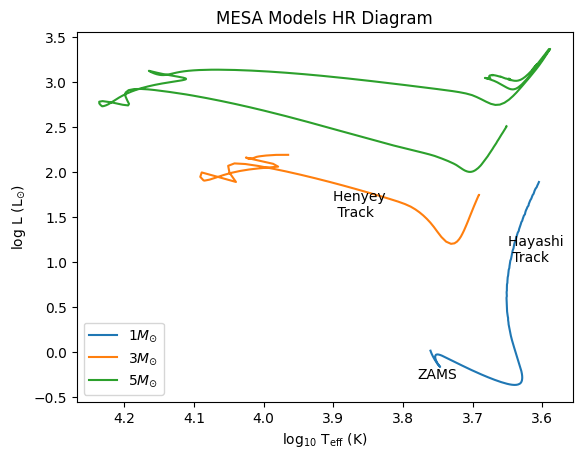

In [7]:
## 1-2 result here
plt.title('MESA Models HR Diagram')

plt.plot(one_m_ms_history_logTeff,
         one_m_ms_history_logL,label=r'$1M_{\odot}$')

plt.plot(three_m_ms_history_logTeff,
         three_m_ms_history_logL,label=r'$3M_{\odot}$')

plt.plot(five_m_ms_history_logTeff,
         five_m_ms_history_logL,label=r'$5M_{\odot}$')



plt.annotate('Hayashi \n Track', xy=(3.65, 1),xycoords='data')
plt.annotate('Henyey \n Track', xy=(3.9, 1.5),xycoords='data')
plt.annotate('ZAMS', xy=(3.78, -0.3),xycoords='data')


plt.gca().invert_xaxis()

plt.legend()
plt.xlabel(r'$\rm{log}_{10}~T_{\rm{eff}}~(\rm{K})$')
plt.ylabel(r'$\rm{log}~L \ (L_{\odot})$')

### **With your larger group, try to answer the following**:

3. Based on the plots, which stars spend more time on the Hayashi track, low mass, or high mass? What about the _Henyey track_? Why might this be?

> Low mass stars on Hayashi, massive on Henyey, the lowest mass stars never reach the Henyey track before reaching ZAMS.

4. Why does the location of the ZAMS move as a function of initial mass?

> More massive stars reach the ZAMS with higher effective temperatures due to hotter and denser cores.

5. What might an stellar object that never reaches the main-sequence look like? Is that a star?

> Brown dwarfs stars are substellar object not quite massive enough to burn H all the way to He but do experience Deuterium burning in their cores. These oject range is about less than $0.085M_{\odot}$ (75 times the mass of Jupiter) down to about $0.05M_{\odot}$. Below this, no fusion occurs, **Planets**!